In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data = load_diabetes(as_frame=True)
df = data.frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:

X = df.drop('target', axis=1)
y = df['target']

X.shape, y.shape


((442, 10), (442,))

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
lin = LinearRegression()
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

rmse_lin, r2_lin

(np.float64(53.85344583676593), 0.4526027629719195)

In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
r2_ridge = r2_score(y_test, pred_ridge)

rmse_ridge, r2_ridge


(np.float64(55.47446204180109), 0.41915292635986556)

In [11]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

import numpy as np
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
r2_lasso = r2_score(y_test, pred_lasso)

rmse_lasso, r2_lasso

(np.float64(53.65220765436038), 0.45668611945806237)

In [13]:
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train, y_train)

pred_elastic = elastic.predict(X_test)

import numpy as np
rmse_elastic = np.sqrt(mean_squared_error(y_test, pred_elastic))
r2_elastic = r2_score(y_test, pred_elastic)

rmse_elastic, r2_elastic

(np.float64(57.606473086497914), 0.37364841571505814)

In [14]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lin.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso,ElasticNet
0,age,37.904021,45.367377,35.347451,41.385384
1,sex,-241.964362,-76.666086,-231.906664,-43.389860
2,bmi,542.428759,291.338832,551.303242,219.917202
3,bp,347.703844,198.995817,341.313469,154.182517
4,s1,-931.488846,-0.530310,-483.567140,13.827544
5,s2,518.062277,-28.577050,165.990532,-5.305924
6,s3,163.419983,-144.511905,-25.834899,-115.773546
7,s4,275.317902,119.260066,216.875803,103.224221
8,s5,736.198859,230.221608,566.815003,179.472215
9,s6,48.670657,112.149830,49.702475,100.040552


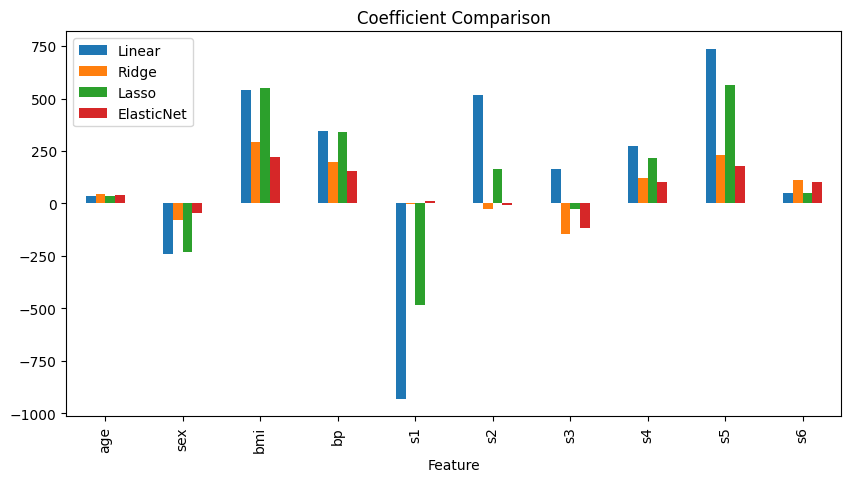

In [15]:
coef_df.set_index('Feature').plot(kind='bar', figsize=(10,5))
plt.title("Coefficient Comparison")
plt.show()


Conclusion - Regularization (Ridge, Lasso, ElasticNet) did not significantly improve accuracy over Linear Regression, but helped control model complexity, with Lasso performing feature selection and Ridge improving stability.
